Answer the questions from the Preamble and Introduction

- For which of the models already studied is the curse of dimensionality relevant and explain why.

Проблема **ПРОКЛЯТИЯ РАЗМЕРНОСТИ** критична для K-Nearest Neighbors (KNN) и K-Means (а также других метрических алгоритмов).

Кончено, любая модель будет страдать от добавления ненужных признаков, но особенно уязвимы те, которые полагаются на близость точек. Алгоритмы работают на идее что близкие точки похожи, но это пояните **близости** весьма условное. В пространствах высокой размерности из-за экспоненциального роста обьема данные становятся разреженными, а расстояния между лююыми точками мало отличимымы.

- What is the difference between PCA and SVD?

SVD - это название метода алгебраического разложения матрицы на три состовляющие и не имеет прямого отношения к ML. Может быть использован где угодно, например, для решения СЛАУ.

PCA (Principal Component Analysis) - ортогональное линейное преобразование данных в новую систему координат. 
Его суть в том, что первая главная компонента  это направление в пространстве исходных признаков, вдоль которого данные имеют наибольшую дисперсию.
Вторая компонента это направление, ортогональное  первому, с наибольшей дисперсией из оставшихся.
И так далее.

PCA можно достичть путем центрирования с последующим применением SVD

- What is the difference between NMF and SVD?

SVD разлагает **любую** матрицу по типу **$A = U \Sigma V^T$**, где **$U V$ ортонормированы**. Такое решение **единственно** и находится **детерминировано**.

NMF SVD разлагает **неотрицательную** матрицу по типу **$A \approx WH$**, где **$W H$ неотрицательны**. Такое решение **не единственно** и находится **итеративно**.

- Describe the structure of the Locally Linear Embedding dimension reduction algorithm.

1. Выбрать K лучших соседей для каждой точки
2. Найти лучшие веса, которые наиболее сильно приближают точку при помощи соседей $\min\limits_{w} \sum\limits_{i} || x_i - \sum\limits_{j \ in \ соседи(x_i)} w_{ij} x_j||$
3. Фиксируем эти веса и теперь ищем координаты точек в новом пространве малой размерности d. Требуем чтобы в новом пространстве точки получались из соседей с этими же весами. $\min\limits_{Y} \sum\limits_{i} || y_i - \sum\limits_{j \ in \ соседи(y_i)} w_{ij} y_j||$

Classification with Sparse Features

In [1]:
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
import numpy as np


- Load the "Book Recommendation Dataset" (source).

In [2]:
users = pd.read_csv(
    'data/Users.csv',
).dropna()
users.dtypes

User-ID       int64
Location        str
Age         float64
dtype: object

In [3]:
(users['Age'] == users['Age'].astype(int)).all()


np.True_

In [4]:
users['Age'] = users['Age'].astype(int)
users.dtypes

User-ID     int64
Location      str
Age         int64
dtype: object

In [5]:
ratings = pd.read_csv(
    'data/ratings.csv'
).dropna()
ratings.dtypes


User-ID        int64
ISBN             str
Book-Rating    int64
dtype: object

In [6]:
f"users {len(users)}, ratings {len(ratings)}" 

'users 168096, ratings 1149780'

In [7]:
common_users = set(ratings['User-ID']).intersection(set(users['User-ID']))
print(f'Пользователей с данными о возрасте {len(users)}')
print(f'Пользователей с данными о рейтинге {ratings['User-ID'].nunique()}')
print(f'Пользователей с данными о возрасте с рейтингом {len(common_users)}')


Пользователей с данными о возрасте 168096
Пользователей с данными о рейтинге 105283
Пользователей с данными о возрасте с рейтингом 62107


In [8]:
ratings = ratings[ratings['User-ID'].isin(common_users)]
users = users[users['User-ID'].isin(common_users)]


- Create a matrix of user-book interactions. Using Sparse Matrices.

In [9]:
users_ids = ratings['User-ID'].unique()
books_ids = ratings['ISBN'].unique()

users_to_idx = {user: i for i, user in enumerate(users_ids)}
books_to_idx = {book: i for i, book in enumerate(books_ids)}

row = ratings['User-ID'].map(users_to_idx).values
col = ratings['ISBN'].map(books_to_idx).values

data = ratings['Book-Rating'].values

X = csr_matrix((data, (row, col)), shape=(len(users_ids), len(books_ids))).tocsr()

y = users.set_index('User-ID').loc[users_ids]['Age'].values


In [10]:
print(f"shape X = {X.shape}")
print(f"y shape = {y.shape}")

shape X = (62107, 285089)
y shape = (62107,)


In [11]:
nnz = X.nnz
total = X.shape[0] * X.shape[1]
density = nnz / total
sparsity = 1 - density

print(f"не ноль: {nnz}")
print(f"Всего: {total}")
print(f"плотность: {density:.6%}")
print(f"разреженность: {sparsity:.6%}")

не ноль: 840288
Всего: 17706022523
плотность: 0.004746%
разреженность: 99.995254%


- Split the dataset into training, valid, and test parts.


In [12]:
n_users = X.shape[0]
indices = np.arange(n_users)

train_valid_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=21)
train_idx, valid_idx = train_test_split(train_valid_idx, test_size=0.25, random_state=21)

X_train = X[train_idx]
y_train = y[train_idx]
X_valid = X[valid_idx]
y_valid = y[valid_idx]
X_test = X[test_idx]
y_test = y[test_idx]

- Build linear and random forest models to predict user age based on user-book interactions. Do not forget to choose optimal parameters.


In [18]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import time
import umap
import matplotlib.pyplot as plt

In [14]:
ridge = Ridge(random_state=21)
param_grid_ridge = {'alpha': [0.1, 1.0, 10.0, 100.0]}
grid_ridge = GridSearchCV(ridge, param_grid_ridge, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)


In [15]:
start = time.time()
grid_ridge.fit(X_train, y_train)
time_ridge = time.time() - start


In [20]:
y_pred_ridge = grid_ridge.predict(X_valid)
mae_ridge = mean_absolute_error(y_valid, y_pred_ridge)
rmse_ridge = root_mean_squared_error(y_valid, y_pred_ridge)
r2_ridge = r2_score(y_valid, y_pred_ridge)
print(f"Лучший alpha: {grid_ridge.best_params_['alpha']}")
print(f"MAE: {mae_ridge:.2f}, RMSE: {rmse_ridge:.2f}, R2: {r2_ridge:.3f}")
print(f"Время обучения: {time_ridge:.2f} сек")

Лучший alpha: 100.0
MAE: 11.91, RMSE: 15.95, R2: -0.164
Время обучения: 18.33 сек


Что-то пошло не так...
Как насчет проанализировать целевую переменную на выбросы

In [21]:
age_data = users['Age'].values
print("статистики:")
print(f"mean: {np.mean(age_data):.2f}")
print(f"median: {np.median(age_data):.2f}")
print(f"std: {np.std(age_data):.2f}")
print(f"min: {np.min(age_data)}")
print(f"max: {np.max(age_data)}")
print(f"1 percentile: {np.percentile(age_data, 1)}")
print(f"99 percentile: {np.percentile(age_data, 99)}")

статистики:
mean: 35.49
median: 33.00
std: 14.74
min: 0
max: 244
1 percentile: 13.0
99 percentile: 72.0


C:\Users\artem\AppData\Local\Temp\ipykernel_3988\2002283676.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(age_data, vert=False)


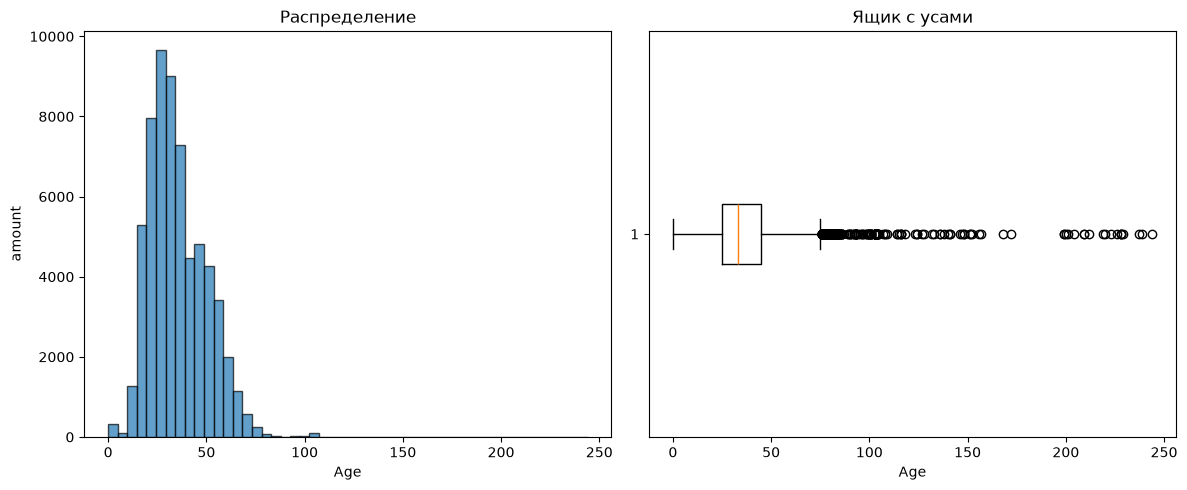

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(age_data, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('amount')

axes[1].boxplot(age_data, vert=False)
axes[1].set_title('Ящик с усами')
axes[1].set_xlabel('Age')
plt.tight_layout()
plt.show()

In [29]:
Q1 = np.percentile(age_data, 25)
Q3 = np.percentile(age_data, 75)
IQR = Q3 - Q1
lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR
outliers = (age_data < lower_bound) | (age_data > upper_bound)
print(f"выбросы: {np.sum(outliers)}")
print(f"границы: lower {lower_bound:.2f}, upper {upper_bound:.2f}")

выбросы: 402
границы: lower 0.00, upper 75.00


In [30]:
reasonable_min = 10
reasonable_max = 90
age_clean = age_data[(age_data >= reasonable_min) & (age_data <= reasonable_max)]
print(f"after deletion [{reasonable_min}, {reasonable_max}] осталось {len(age_clean)} из {len(age_data)}")

after deletion [10, 90] осталось 61520 из 62107


In [31]:
valid_user_mask = users['Age'].between(reasonable_min, reasonable_max)
valid_users = users[valid_user_mask]['User-ID'].values

In [32]:
users_ids = ratings['User-ID'].unique() 

In [34]:
user_id_to_age = users.set_index('User-ID')['Age'].to_dict()
age_mask = np.array([(reasonable_min <= user_id_to_age[uid] <= reasonable_max) for uid in users_ids])
X_filtered = X[age_mask]
y_filtered = y[age_mask]
print(f"X: {X_filtered.shape}, y: {y_filtered.shape}")

X: (61520, 285089), y: (61520,)


In [35]:
X = X_filtered
y = y_filtered

In [36]:
nnz = X.nnz
total = X.shape[0] * X.shape[1]
density = nnz / total
sparsity = 1 - density

print(f"не ноль: {nnz}")
print(f"Всего: {total}")
print(f"плотность: {density:.6%}")
print(f"разреженность: {sparsity:.6%}")

не ноль: 830386
Всего: 17538675280
плотность: 0.004735%
разреженность: 99.995265%


In [ ]:
indices = np.arange(X.shape[0])
train_valid_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=21)
train_idx, valid_idx = train_test_split(train_valid_idx, test_size=0.25, random_state=21)

X_train_orig = X[train_idx]
y_train = y[train_idx]
X_valid_orig = X[valid_idx]
y_valid = y[valid_idx]
X_test_orig = X[test_idx]
y_test = y[test_idx]

print(f"train: {X_train_orig.shape}, valid: {X_valid_orig.shape}, test: {X_test_orig.shape}")

Train: (36912, 285089), Valid: (12304, 285089), Test: (12304, 285089)


In [55]:
ridge = Ridge(random_state=21)
param_grid_ridge = {'alpha': [0.1, 1.0, 10.0, 100.0]}
grid_ridge = GridSearchCV(ridge, param_grid_ridge, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
start = time.time()
grid_ridge.fit(X_train_orig, y_train)
time_ridge_orig = time.time() - start


In [56]:
y_pred_ridge_valid = grid_ridge.predict(X_valid_orig)
mae_ridge_orig = mean_absolute_error(y_valid, y_pred_ridge_valid)
rmse_ridge_orig = root_mean_squared_error(y_valid, y_pred_ridge_valid)
r2_ridge_orig = r2_score(y_valid, y_pred_ridge_valid)
print(f"Ridge (orig) - best alpha: {grid_ridge.best_params_['alpha']}, MAE={mae_ridge_orig:.2f}, RMSE={rmse_ridge_orig:.2f}, R2={r2_ridge_orig:.3f}, время={time_ridge_orig:.2f} с")


Ridge (orig) - best alpha: 100.0, MAE=11.36, RMSE=14.54, R2=-0.144, время=19.29 с


In [57]:

rf = RandomForestRegressor(random_state=21, n_jobs=-1)
param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [10, 20]}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=2, scoring='neg_mean_absolute_error', n_jobs=-1)
start = time.time()
grid_rf.fit(X_train_orig, y_train)
time_rf_orig = time.time() - start


In [58]:
y_pred_rf_valid = grid_rf.predict(X_valid_orig)
mae_rf_orig = mean_absolute_error(y_valid, y_pred_rf_valid)
rmse_rf_orig = root_mean_squared_error(y_valid, y_pred_rf_valid)
r2_rf_orig = r2_score(y_valid, y_pred_rf_valid)
print(f"RF (orig) - best params: {grid_rf.best_params_}, MAE={mae_rf_orig:.2f}, RMSE={rmse_rf_orig:.2f}, R2={r2_rf_orig:.3f}, время={time_rf_orig:.2f} с")

RF (orig) - best params: {'max_depth': 20, 'n_estimators': 100}, MAE=11.05, RMSE=13.55, R2=0.006, время=172.94 с


- Use PCA and UMAP to reduce the dimensionality of the features.


- Build linear model and random forest model on the compressed features.


- Compare fitting time and quality for models from iv and vi.

In [59]:
n_pca = 100
svd = TruncatedSVD(n_components=n_pca, random_state=21)
start = time.time()
X_train_pca = svd.fit_transform(X_train_orig)
X_valid_pca = svd.transform(X_valid_orig)
X_test_pca = svd.transform(X_test_orig)
time_pca = time.time() - start
explained_var = svd.explained_variance_ratio_.sum()
print(f"PCA: {n_pca} компонент, объяснённая дисперсия = {explained_var:.3f}, время={time_pca:.2f} с")

PCA: 100 компонент, объяснённая дисперсия = 0.235, время=8.38 с


In [60]:
ridge_pca = Ridge(alpha=grid_ridge.best_params_['alpha'])
start = time.time()
ridge_pca.fit(X_train_pca, y_train)
time_ridge_pca = time.time() - start


In [61]:
y_pred_ridge_pca_valid = ridge_pca.predict(X_valid_pca)
mae_ridge_pca = mean_absolute_error(y_valid, y_pred_ridge_pca_valid)
rmse_ridge_pca = root_mean_squared_error(y_valid, y_pred_ridge_pca_valid)
r2_ridge_pca = r2_score(y_valid, y_pred_ridge_pca_valid)
print(f"Ridge+PCA: MAE={mae_ridge_pca:.2f}, RMSE={rmse_ridge_pca:.2f}, R2={r2_ridge_pca:.3f}, время={time_ridge_pca:.2f} с")



Ridge+PCA: MAE=11.04, RMSE=13.54, R2=0.008, время=0.04 с


In [62]:
rf_pca = RandomForestRegressor(**grid_rf.best_params_, random_state=21, n_jobs=-1)
start = time.time()
rf_pca.fit(X_train_pca, y_train)
time_rf_pca = time.time() - start


In [63]:
y_pred_rf_pca_valid = rf_pca.predict(X_valid_pca)
mae_rf_pca = mean_absolute_error(y_valid, y_pred_rf_pca_valid)
rmse_rf_pca = root_mean_squared_error(y_valid, y_pred_rf_pca_valid)
r2_rf_pca = r2_score(y_valid, y_pred_rf_pca_valid)
print(f"RF+PCA: MAE={mae_rf_pca:.2f}, RMSE={rmse_rf_pca:.2f}, R2={r2_rf_pca:.3f}, время={time_rf_pca:.2f} с")

RF+PCA: MAE=10.81, RMSE=13.37, R2=0.033, время=13.43 с


In [64]:
umap_reducer = umap.UMAP(n_components=5, random_state=21, n_neighbors=15, min_dist=0.1)
start = time.time()
X_train_umap = umap_reducer.fit_transform(X_train_pca)
X_valid_umap = umap_reducer.transform(X_valid_pca)
X_test_umap = umap_reducer.transform(X_test_pca)
time_umap = time.time() - start
print(f"UMAP (после PCA): время={time_umap:.2f} с")

c:\Users\artem\Desktop\books\school21\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP (после PCA): время=60.02 с


In [67]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_umap = imputer.fit_transform(X_train_umap)
X_valid_umap = imputer.transform(X_valid_umap)
X_test_umap = imputer.transform(X_test_umap)

In [68]:
ridge_umap = Ridge(alpha=grid_ridge.best_params_['alpha'])
start = time.time()
ridge_umap.fit(X_train_umap, y_train)
time_ridge_umap = time.time() - start


In [69]:
y_pred_ridge_umap_valid = ridge_umap.predict(X_valid_umap)
mae_ridge_umap = mean_absolute_error(y_valid, y_pred_ridge_umap_valid)
rmse_ridge_umap = root_mean_squared_error(y_valid, y_pred_ridge_umap_valid)
r2_ridge_umap = r2_score(y_valid, y_pred_ridge_umap_valid)
print(f"Ridge+UMAP: MAE={mae_ridge_umap:.2f}, RMSE={rmse_ridge_umap:.2f}, R2={r2_ridge_umap:.3f}, время={time_ridge_umap:.2f} с")

Ridge+UMAP: MAE=11.07, RMSE=13.56, R2=0.004, время=0.00 с


In [70]:
rf_umap = RandomForestRegressor(**grid_rf.best_params_, random_state=21, n_jobs=-1)
start = time.time()
rf_umap.fit(X_train_umap, y_train)
time_rf_umap = time.time() - start


In [71]:
y_pred_rf_umap_valid = rf_umap.predict(X_valid_umap)
mae_rf_umap = mean_absolute_error(y_valid, y_pred_rf_umap_valid)
rmse_rf_umap = root_mean_squared_error(y_valid, y_pred_rf_umap_valid)
r2_rf_umap = r2_score(y_valid, y_pred_rf_umap_valid)
print(f"RF+UMAP: MAE={mae_rf_umap:.2f}, RMSE={rmse_rf_umap:.2f}, R2={r2_rf_umap:.3f}, время={time_rf_umap:.2f} с")

RF+UMAP: MAE=11.01, RMSE=13.60, R2=-0.000, время=1.58 с


In [73]:
y_pred_ridge_test_orig = grid_ridge.best_estimator_.predict(X_test_orig)
y_pred_rf_test_orig = grid_rf.best_estimator_.predict(X_test_orig)
mae_ridge_test_orig = mean_absolute_error(y_test, y_pred_ridge_test_orig)
rmse_ridge_test_orig = root_mean_squared_error(y_test, y_pred_ridge_test_orig)
r2_ridge_test_orig = r2_score(y_test, y_pred_ridge_test_orig)
mae_rf_test_orig = mean_absolute_error(y_test, y_pred_rf_test_orig)
rmse_rf_test_orig = root_mean_squared_error(y_test, y_pred_rf_test_orig)
r2_rf_test_orig = r2_score(y_test, y_pred_rf_test_orig)



In [74]:
y_pred_ridge_test_pca = ridge_pca.predict(X_test_pca)
y_pred_rf_test_pca = rf_pca.predict(X_test_pca)
mae_ridge_test_pca = mean_absolute_error(y_test, y_pred_ridge_test_pca)
rmse_ridge_test_pca = root_mean_squared_error(y_test, y_pred_ridge_test_pca)
r2_ridge_test_pca = r2_score(y_test, y_pred_ridge_test_pca)
mae_rf_test_pca = mean_absolute_error(y_test, y_pred_rf_test_pca)
rmse_rf_test_pca = root_mean_squared_error(y_test, y_pred_rf_test_pca)
r2_rf_test_pca = r2_score(y_test, y_pred_rf_test_pca)



In [75]:
y_pred_ridge_test_umap = ridge_umap.predict(X_test_umap)
y_pred_rf_test_umap = rf_umap.predict(X_test_umap)
mae_ridge_test_umap = mean_absolute_error(y_test, y_pred_ridge_test_umap)
rmse_ridge_test_umap = root_mean_squared_error(y_test, y_pred_ridge_test_umap)
r2_ridge_test_umap = r2_score(y_test, y_pred_ridge_test_umap)
mae_rf_test_umap = mean_absolute_error(y_test, y_pred_rf_test_umap)
rmse_rf_test_umap = root_mean_squared_error(y_test, y_pred_rf_test_umap)
r2_rf_test_umap = r2_score(y_test, y_pred_rf_test_umap)


In [80]:

print(f"{'Модель':<20} {'MAE':<8} {'RMSE':<8} {'R2':<8} {'time':<8}")
print(f"{'Ridge (исх)':<20} {mae_ridge_test_orig:<8.2f} {rmse_ridge_test_orig:<8.2f} {r2_ridge_test_orig:<8.3f} {time_ridge_orig:<8.2f}")
print(f"{'RF (исх)':<20} {mae_rf_test_orig:<8.2f} {rmse_rf_test_orig:<8.2f} {r2_rf_test_orig:<8.3f} {time_rf_orig:<8.2f}")
print(f"{'Ridge+PCA':<20} {mae_ridge_test_pca:<8.2f} {rmse_ridge_test_pca:<8.2f} {r2_ridge_test_pca:<8.3f} {time_ridge_pca:<8.2f}")
print(f"{'RF+PCA':<20} {mae_rf_test_pca:<8.2f} {rmse_rf_test_pca:<8.2f} {r2_rf_test_pca:<8.3f} {time_rf_pca:<8.2f}")
print(f"{'Ridge+UMAP':<20} {mae_ridge_test_umap:<8.2f} {rmse_ridge_test_umap:<8.2f} {r2_ridge_test_umap:<8.3f} {time_ridge_umap:<8.2f}")
print(f"{'RF+UMAP':<20} {mae_rf_test_umap:<8.2f} {rmse_rf_test_umap:<8.2f} {r2_rf_test_umap:<8.3f} {time_rf_umap:<8.2f}")

Модель               MAE      RMSE     R2       time    
Ridge (исх)          11.57    14.83    -0.166   19.29   
RF (исх)             11.17    13.70    0.005    172.94  
Ridge+PCA            11.17    13.69    0.006    0.04    
RF+PCA               10.99    13.60    0.019    13.43   
Ridge+UMAP           11.19    13.72    0.003    0.00    
RF+UMAP              11.19    13.83    -0.013   1.58    


Visualizations

In [81]:
import struct


- Load the MNIST dataset

In [88]:
def read_idx(filename):
    with open(filename, 'rb') as f:
        magic = struct.unpack('>I', f.read(4))[0]
        ndim = (magic & 0xFF)
        dtype = (magic >> 8) & 0xFF
        shape = struct.unpack('>' + 'I'*ndim, f.read(4*ndim))
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)
    return data

train_images = read_idx('./data/train-images.idx3-ubyte') 
train_labels = read_idx('./data/train-labels.idx1-ubyte')
test_images = read_idx('./data/t10k-images.idx3-ubyte')
test_labels = read_idx('./data/t10k-labels.idx1-ubyte')

print(f"\nTraining images: {train_images.shape}")  
print(f"Training labels: {train_labels.shape}")   
print(f"Test images: {test_images.shape}")        
print(f"Test labels: {test_labels.shape}")  


Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


- Represent each digit image as a vector.


In [89]:
X_train = train_images.reshape(train_images.shape[0], -1).astype(np.float32) / 255.0
y_train = train_labels.astype(np.int64)

In [90]:
n_samples = 5000
X = X_train[:n_samples]
y = y_train[:n_samples]

- Transform vectors up to 2 dimensions using PCA, SVD, Randomized-SVD, TSNE, UMAP, and LLE.

In [ ]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE, LocallyLinearEmbedding
import umap
import time

methods = {}

start = time.time()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
methods['PCA'] = (X_pca, time.time()-start)

svd = TruncatedSVD(n_components=2)
X_svd = svd.fit_transform(X)
methods['SVD'] = (X_svd, time.time()-start)

r_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=21)
X_r_svd = r_svd.fit_transform(X)
methods['Randomized-SVD'] = (X_r_svd, time.time()-start)

tsne = TSNE(n_components=2, perplexity=30, random_state=21, n_jobs=-1)
X_tsne = tsne.fit_transform(X)
methods['t-SNE'] = (X_tsne, time.time()-start)

umap_reducer = umap.UMAP(n_components=2, random_state=21, n_neighbors=15, min_dist=0.1)
X_umap = umap_reducer.fit_transform(X)
methods['UMAP'] = (X_umap, time.time()-start)

lle = LocallyLinearEmbedding(n_components=2, n_neighbors=30)
X_lle = lle.fit_transform(X)
methods['LLE'] = (X_lle, time.time()-start)

c:\Users\artem\Desktop\books\school21\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


- Propose metrics and compare models based on how well they separate digit classes.

C:\Users\artem\AppData\Local\Temp\ipykernel_3988\1931522122.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


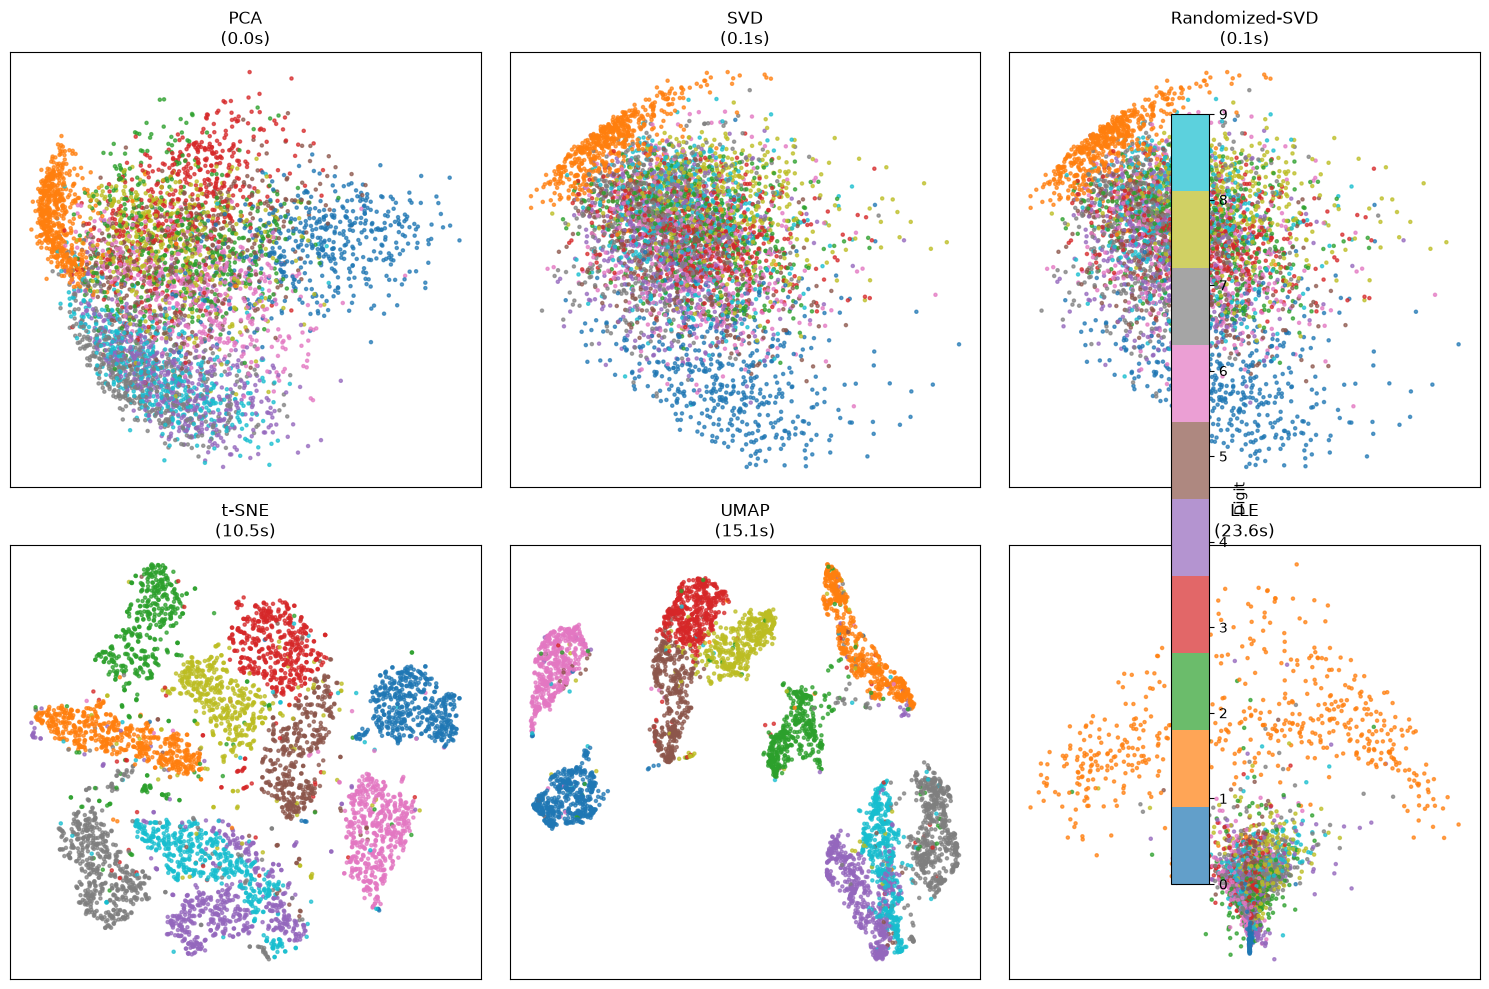

In [92]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for ax, (name, (data, dur)) in zip(axes, methods.items()):
    scatter = ax.scatter(data[:,0], data[:,1], c=y, cmap='tab10', s=5, alpha=0.7)
    ax.set_title(f"{name}\n({dur:.1f}s)")
    ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(scatter, ax=axes.tolist(), ticks=range(10), label='Digit')
plt.tight_layout()
plt.show()

In [94]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


In [95]:

print(f"{'Method':<15} {'Silhouette':<12} {'CH-score':<12} {'DB-score':<10}")
for name, (data, _) in methods.items():
    sil = silhouette_score(data, y)
    ch = calinski_harabasz_score(data, y)
    db = davies_bouldin_score(data, y)
    print(f"{name:<15} {sil:<12.3f} {ch:<12.1f} {db:<10.3f}")

Method          Silhouette   CH-score     DB-score  
PCA             0.031        919.0        6.475     
SVD             -0.019       458.3        13.491    
Randomized-SVD  -0.019       458.3        13.492    
t-SNE           0.308        2681.9       1.409     
UMAP            0.367        4535.7       1.353     
LLE             -0.099       344.0        18.149    


Image compression using SVD

In [123]:
import cv2
from PIL import Image
import os


- Select 3 random grayscale images and load them into matrix using Python.


- Decompose the matrix using SVD.
- Vary the rank, compute a low-rank approximation of the original matrix, and plot the recovered image. Use up to 10 different ranks. What does the singular value spectrum look like and how many modes are needed for good image reconstruction?
- Plot the distribution of explained variance versus rank. Explain what "explained variance" is.

In [124]:
def load_grayscale_image(path):
    img = Image.open(path).convert('L')
    return np.array(img, dtype=np.float64)

paths = ['data/bird.jpg', 'data/beach.jpg', 'data/forest.jpg']
images = [load_grayscale_image(p) for p in paths]

ranks = [1, 5, 10, 20, 50, 100, 150, 200, 250, 300]

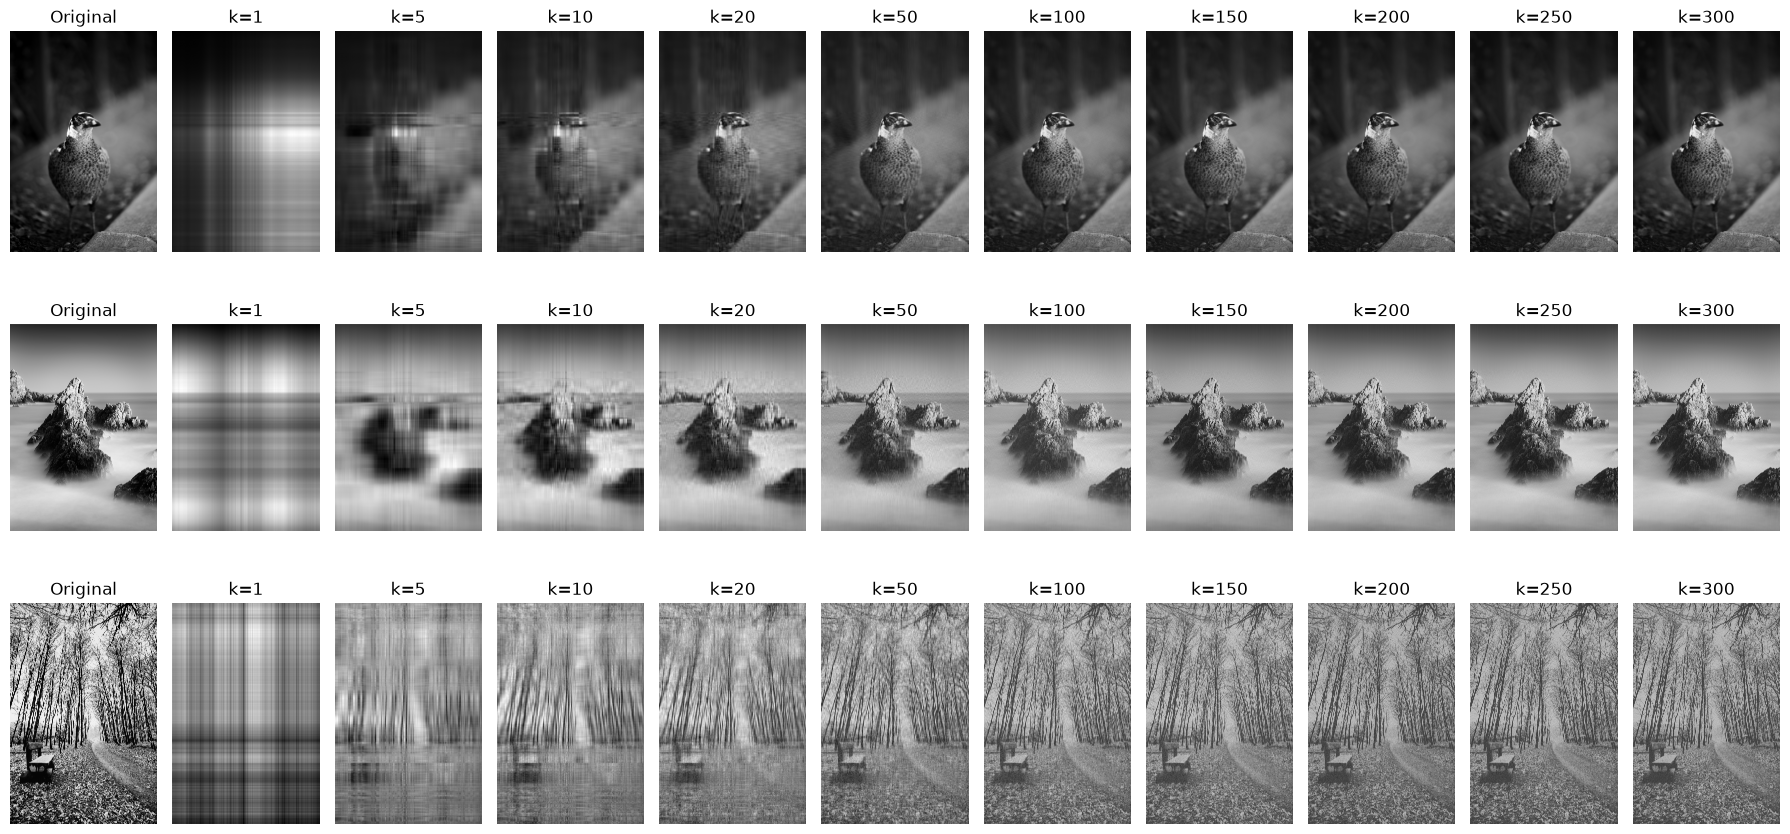

In [125]:
def low_rank_approx(A, k):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

fig, axes = plt.subplots(len(images), len(ranks)+1, figsize=(18, 3*len(images)))
for i, img in enumerate(images):
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')
    
    for j, k in enumerate(ranks):
        recon = low_rank_approx(img, k)
        axes[i, j+1].imshow(recon, cmap='gray')
        axes[i, j+1].set_title(f'k={k}')
        axes[i, j+1].axis('off')
plt.tight_layout()
plt.show()

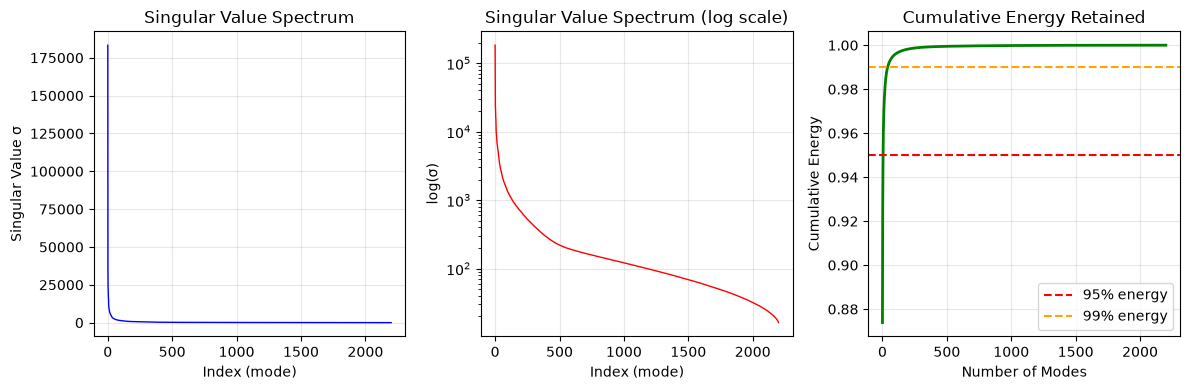

Image size: (3302, 2201)
Total singular values: 2201
Rank of image: 2201

Modes needed for 95% energy: 6
Modes needed for 99% energy: 42
Compression ratio at 95%: 220.1x


In [129]:
U, s, Vt = np.linalg.svd(images[0], full_matrices=False)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(s, 'b-', linewidth=1)
plt.title('Singular Value Spectrum')
plt.xlabel('Index (mode)')
plt.ylabel('Singular Value σ')
plt.grid(True, alpha=0.3)
plt.subplot(1, 3, 2)
plt.semilogy(s, 'r-', linewidth=1)
plt.title('Singular Value Spectrum (log scale)')
plt.xlabel('Index (mode)')
plt.ylabel('log(σ)')
plt.grid(True, alpha=0.3)

cumulative_energy = np.cumsum(s**2) / np.sum(s**2)
plt.subplot(1, 3, 3)
plt.plot(cumulative_energy, 'g-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% energy')
plt.axhline(y=0.99, color='orange', linestyle='--', label='99% energy')
plt.title('Cumulative Energy Retained')
plt.xlabel('Number of Modes')
plt.ylabel('Cumulative Energy')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

energy_95 = np.where(cumulative_energy >= 0.95)[0][0] + 1
energy_99 = np.where(cumulative_energy >= 0.99)[0][0] + 1

print(f"Image size: {images[0].shape}")
print(f"Total singular values: {len(s)}")
print(f"Rank of image: {np.linalg.matrix_rank(images[0])}")
print(f"\nModes needed for 95% energy: {energy_95}")
print(f"Modes needed for 99% energy: {energy_99}")
print(f"Compression ratio at 95%: {images[0].size / (energy_95 * (images[0].shape[0] + images[0].shape[1])):.1f}x")

Background detection using SVD

- Load "Video_008.avi" (source — bmc_real.zip).


In [130]:
def video_to_matrix(video_path, max_frames=None):
    cap = cv2.VideoCapture(video_path)
    
    frames = []
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        flattened = gray.flatten()
        frames.append(flattened)
        
        frame_count += 1
        if max_frames and frame_count >= max_frames:
            break
    
    cap.release()
    
    video_matrix = np.column_stack(frames)
    
    
    return video_matrix, frames

def matrix_to_frame(matrix_column, height, width):
    return matrix_column.reshape(height, width)

def decompose_video_svd(video_matrix):
    U, s, Vt = np.linalg.svd(video_matrix, full_matrices=False)
    
    print(f"U shape: {U.shape}")
    print(f"s shape: {s.shape}")
    print(f"Vt shape: {Vt.shape}")
    
    return U, s, Vt

def reconstruct_frame_from_svd(U, s, Vt, frame_idx, rank):
    U_k = U[:, :rank]
    s_k = s[:rank]
    Vt_k = Vt[:rank, :]
    
    reconstructed_matrix = U_k @ np.diag(s_k) @ Vt_k
    
    frame_vector = reconstructed_matrix[:, frame_idx]
    
    return frame_vector


- Represent the video as a matrix and decompose it using SVD.

(76800, 100)
U shape: (76800, 100)
s shape: (100,)
Vt shape: (100, 100)


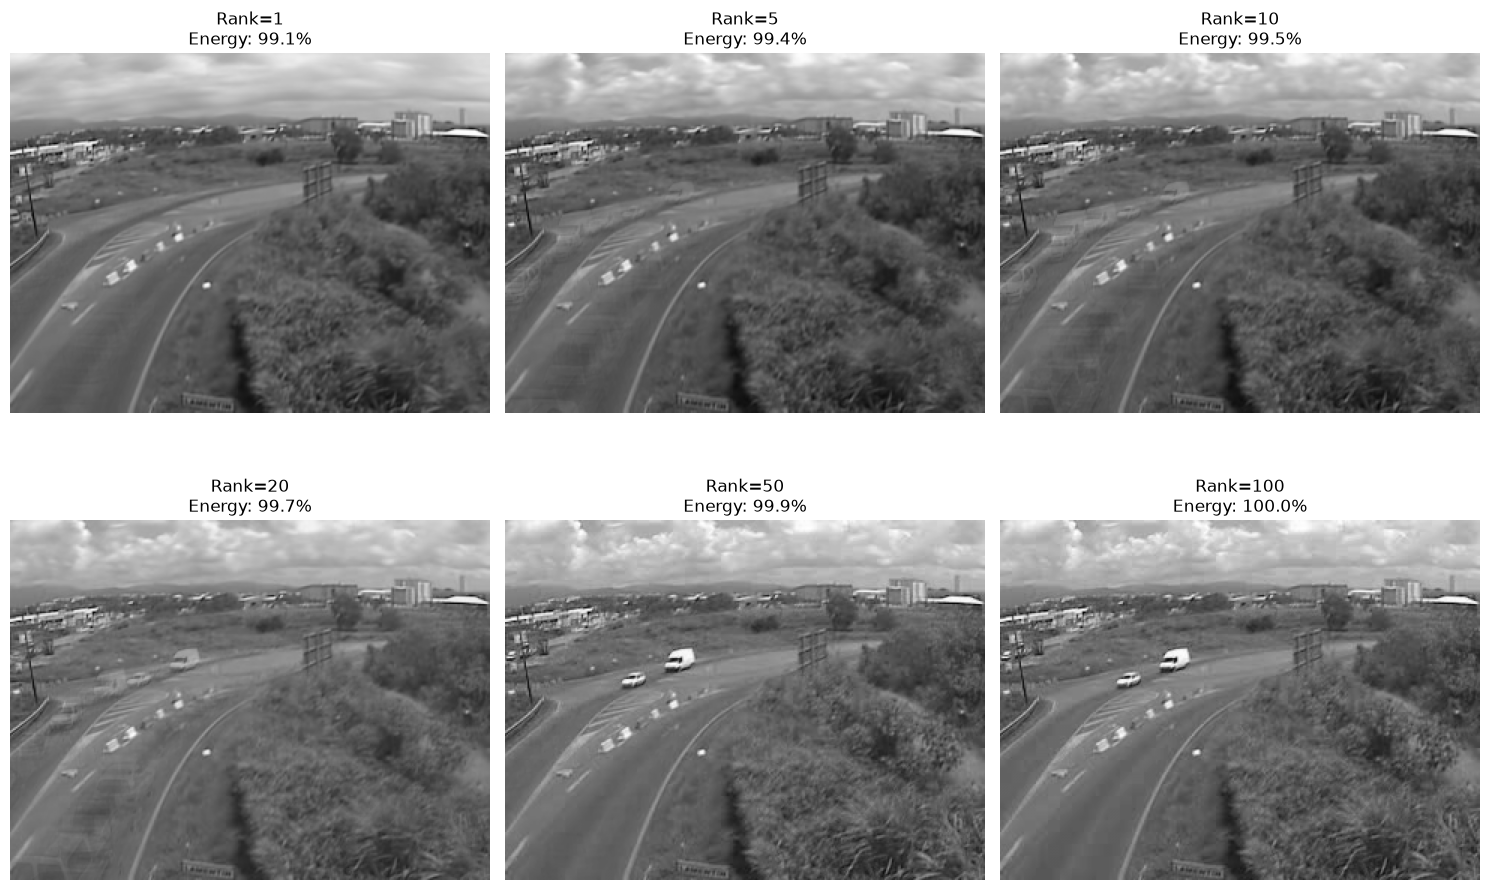

In [131]:

video_path = './data/Video_008.avi'
height, width = 240, 320  

video_matrix, original_frames = video_to_matrix(video_path, max_frames=100)
print(video_matrix.shape)
U, s, Vt = decompose_video_svd(video_matrix)

first_frame_idx = 0
ranks_to_try = [1, 5, 10, 20, 50, 100]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, rank in enumerate(ranks_to_try):
    reconstructed_vector = reconstruct_frame_from_svd(U, s, Vt, first_frame_idx, rank)
    reconstructed_frame = matrix_to_frame(reconstructed_vector, height, width)
    
    total_energy = np.sum(s**2)
    energy_retained = np.sum(s[:rank]**2) / total_energy * 100
    
    axes[idx].imshow(reconstructed_frame, cmap='gray')
    axes[idx].set_title(f'Rank={rank}\nEnergy: {energy_retained:.1f}%')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

- Reconstruct the first frame using low-rank approximation. What rank should you use to get the background?

we have to use rank 1 to get the background